<a href="https://colab.research.google.com/github/PradenaTiara/Machine-Learning/blob/main/Klaster__672022028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.cluster import hierarchy
from scipy.spatial import distance_matrix
from matplotlib import pyplot as plt
from sklearn import manifold, datasets
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
%matplotlib inline

In [ ]:
 !wget -O cars_clus.csv https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cars_clus.csv

--2024-04-28 15:34:10--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/ML0101ENv3/labs/cars_clus.csv
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17774 (17K) [text/csv]
Saving to: ‘cars_clus.csv’

cars_clus.csv       100%[===================>]  17.36K  --.-KB/s    in 0s      

2024-04-28 15:34:10 (122 MB/s) - ‘cars_clus.csv’ saved [17774/17774]



In [ ]:
filename = 'cars_clus.csv'
df = pd.read_csv(filename)
print("Banyaknya dataset:", df.shape)
df.head(5)

Banyaknya dataset: (159, 16)


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [ ]:
print("Banyaknya dataset sebelum dibersihkan:", df.size)
df[['sales','resale','type','price','engine_s','horsepow','wheelbas','width','length','curb_wgt','fuel_cap','mpg','lnsales']] = df[['sales','resale','type','price','engine_s','horsepow','wheelbas','width','length','curb_wgt','fuel_cap','mpg','lnsales']].apply(pd.to_numeric, errors = 'coerce')
df = df.dropna()
df = df.reset_index(drop=True)
print("Banyaknya dataset sebelum dibersihkan:", df.size)
df.head(5)

Banyaknya dataset sebelum dibersihkan: 2544
Banyaknya dataset sebelum dibersihkan: 1872


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.0,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2.828,0.0
1,Acura,TL,39.384,19.875,0.0,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,3.673,0.0
2,Acura,RL,8.588,29.725,0.0,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,2.150,0.0
3,Audi,A4,20.397,22.255,0.0,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,3.015,0.0
4,Audi,A6,18.780,23.555,0.0,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,2.933,0.0


In [ ]:
#pilih kolom yang dibutuhkan
fitur_set = df[['engine_s','horsepow','mpg']]

In [ ]:
#normalisasi
from sklearn.preprocessing import MinMaxScaler
x = fitur_set.values
min_max_scaler = MinMaxScaler()
fitur_set_mtx = min_max_scaler.fit_transform(x)
fitur_set_mtx [0:5]


array([[0.11428571, 0.21518987, 0.43333333],
       [0.31428571, 0.43037975, 0.33333333],
       [0.35714286, 0.39240506, 0.23333333],
       [0.11428571, 0.24050633, 0.4       ],
       [0.25714286, 0.36708861, 0.23333333]])

In [ ]:
import scipy

leng = fitur_set_mtx.shape[0]
D = scipy.zeros([leng,leng])
for i in range(leng):
  for j in range(leng):
    D[i,j] = scipy.spatial.distance.euclidean(fitur_set_mtx[i], fitur_set_mtx[j])

<ipython-input-38-c70e1b93d4c1>:4: DeprecationWarning: scipy.zeros is deprecated and will be removed in SciPy 2.0.0, use numpy.zeros instead
  D = scipy.zeros([leng,leng])


In [ ]:
import pylab
import scipy.cluster.hierarchy
z = hierarchy.linkage(D,'complete')

<ipython-input-39-f9f612edf1f5>:3: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z = hierarchy.linkage(D,'complete')


In [ ]:
from scipy.cluster.hierarchy import fcluster
max_d = 3
clusters = fcluster(z,max_d,criterion='distance')
clusters

array([2, 4, 4, 2, 4, 1, 4, 4, 4, 3, 4, 4, 3, 3, 4, 2, 4, 4, 4, 4, 1, 2,
       5, 4, 4, 4, 2, 3, 2, 4, 4, 6, 1, 3, 3, 4, 4, 2, 4, 4, 4, 3, 3, 4,
       1, 4, 3, 2, 2, 4, 4, 4, 2, 2, 4, 4, 4, 3, 3, 4, 4, 3, 3, 3, 2, 4,
       4, 4, 4, 3, 4, 2, 2, 4, 3, 3, 4, 4, 4, 3, 1, 2, 4, 4, 4, 4, 4, 3,
       3, 4, 2, 2, 4, 4, 4, 4, 4, 4, 4, 3, 3, 2, 2, 2, 2, 2, 4, 2, 4, 2,
       4, 1, 2, 2, 2, 2, 2], dtype=int32)

In [ ]:
from scipy.cluster.hierarchy import fcluster
k = 5
clusters = fcluster(z,k,criterion='maxclust')
clusters

array([2, 3, 3, 2, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 1, 2,
       4, 3, 3, 3, 2, 3, 2, 3, 3, 5, 1, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3,
       1, 3, 3, 2, 2, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3,
       3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 1, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 2,
       3, 1, 2, 2, 2, 2, 2], dtype=int32)

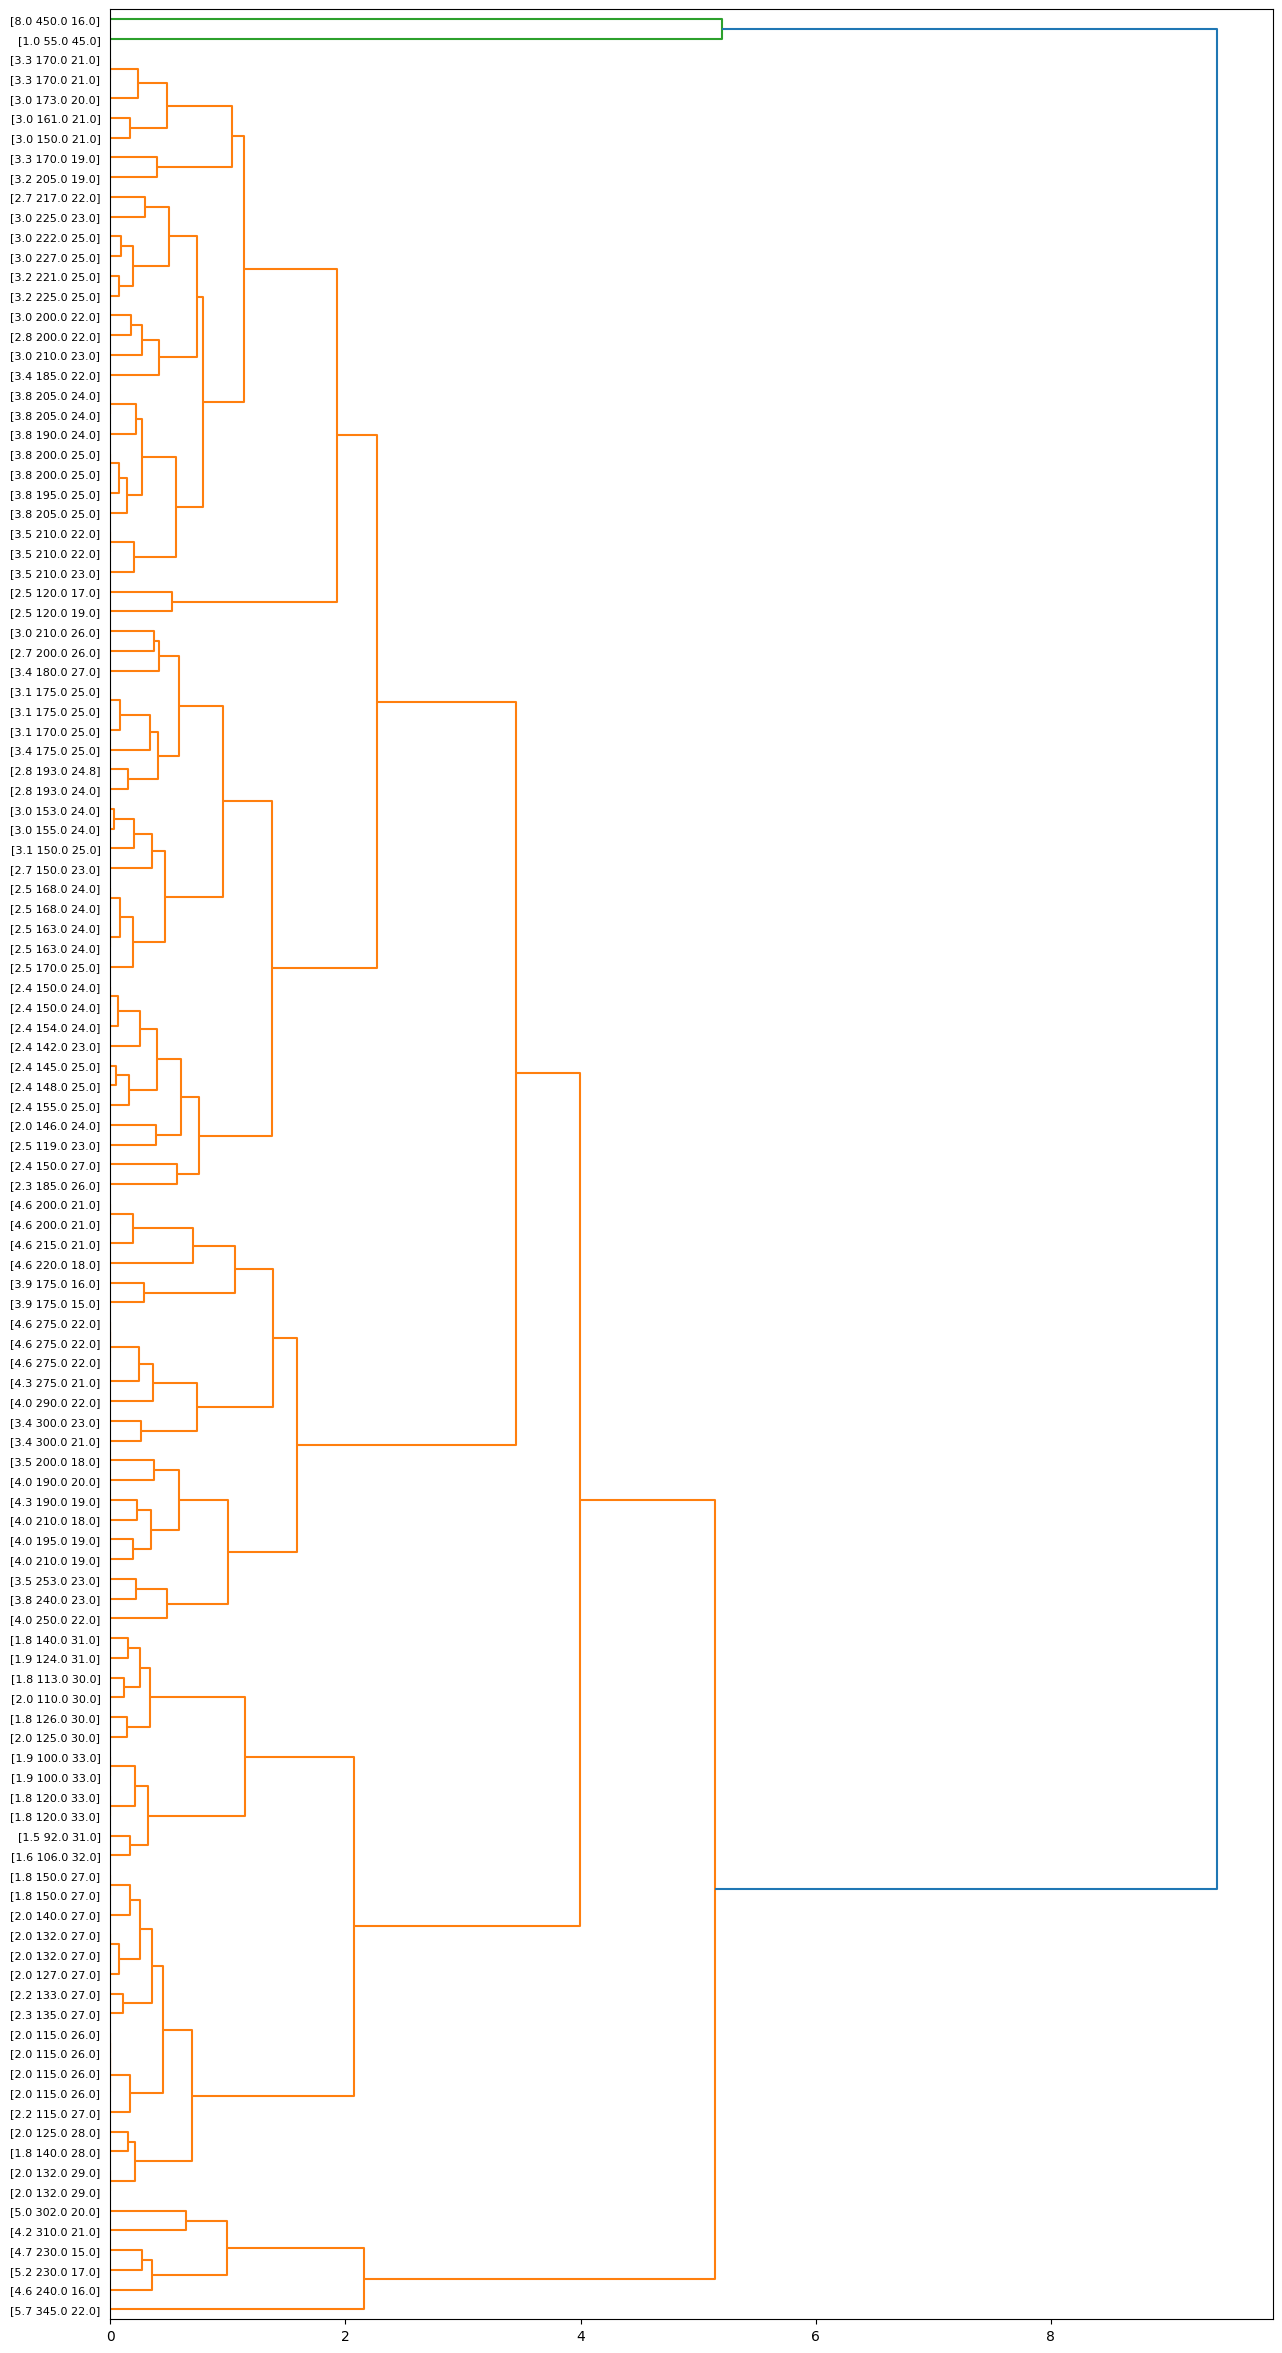

In [ ]:
fig = pylab.figure(figsize=(15,30))

def llf(id):
  return '[%s %s %s]' % (df['engine_s'][id],df['horsepow'][id],df['mpg'][id])

dendro = hierarchy.dendrogram(z, leaf_label_func=llf,leaf_font_size=8,orientation='right')
